# Load Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle as pickle
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import matthews_corrcoef, make_scorer, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier

from classical_data_processing import get_vectorized_data

# Import Data

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = get_vectorized_data()

In [3]:
class_names = pd.read_csv("../data/class_names.csv", index_col=0).to_numpy()
class_names

array([['Irrelevant'],
       ['Negative'],
       ['Neutral'],
       ['Positive']], dtype=object)

# Model

In [4]:
adaboost = AdaBoostClassifier(random_state=42)
matthews_scorer = make_scorer(matthews_corrcoef)

## Hyperparameter Search

In [5]:
param_grid = {
    "n_estimators": [100, 200, 500],
    "learning_rate": [0.7, 0.9, 1.0]
}

grid_search = GridSearchCV(adaboost, param_grid, scoring=matthews_scorer, verbose=3)
grid_search.fit(X_train, y_train)

grid_search.cv_results_

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END learning_rate=0.7, n_estimators=100;, score=0.206 total time= 2.9min
[CV 2/5] END learning_rate=0.7, n_estimators=100;, score=0.218 total time= 2.8min
[CV 3/5] END learning_rate=0.7, n_estimators=100;, score=0.215 total time= 2.9min
[CV 4/5] END learning_rate=0.7, n_estimators=100;, score=0.199 total time= 3.1min
[CV 5/5] END learning_rate=0.7, n_estimators=100;, score=0.206 total time= 2.9min
[CV 1/5] END learning_rate=0.7, n_estimators=200;, score=0.256 total time= 5.7min
[CV 2/5] END learning_rate=0.7, n_estimators=200;, score=0.260 total time= 5.8min
[CV 3/5] END learning_rate=0.7, n_estimators=200;, score=0.238 total time= 5.7min
[CV 4/5] END learning_rate=0.7, n_estimators=200;, score=0.260 total time= 5.2min
[CV 5/5] END learning_rate=0.7, n_estimators=200;, score=0.255 total time= 5.2min
[CV 1/5] END learning_rate=0.7, n_estimators=500;, score=0.293 total time=12.4min
[CV 2/5] END learning_rate=0.7, n_esti

{'mean_fit_time': array([170.70546103, 324.80909581, 900.40653663, 215.93041635,
        519.82434134, 805.71320825, 130.4369103 , 259.95138764,
        660.02143087]),
 'std_fit_time': array([  5.34779341,  17.16917915, 172.91553479,   7.42523459,
         41.60933146, 198.70700099,   0.36368339,   1.75199212,
          5.02059075]),
 'mean_score_time': array([ 3.78859468,  7.2165431 , 27.4204329 ,  6.3608469 , 15.53944259,
        21.95355325,  3.77473521,  7.55051494, 20.01054811]),
 'std_score_time': array([0.11411194, 0.18859179, 7.82549483, 0.25778773, 1.94587876,
        5.62704612, 0.01880039, 0.10061158, 0.4280855 ]),
 'param_learning_rate': masked_array(data=[0.7, 0.7, 0.7, 0.9, 0.9, 0.9, 1.0, 1.0, 1.0],
              mask=[False, False, False, False, False, False, False, False,
                    False],
        fill_value=1e+20),
 'param_n_estimators': masked_array(data=[100, 200, 500, 100, 200, 500, 100, 200, 500],
              mask=[False, False, False, False, False, Fa

In [6]:
best_model = grid_search.best_estimator_

## Training

In [7]:
train_score = best_model.score(X_train, y_train)

print("Training Score: ", train_score)

Training Score:  0.47739622813827115


## Validation

In [8]:
val_score = best_model.score(X_val, y_val)

print("Validation Score: ", val_score)

Validation Score:  0.486


## Test

In [9]:
test_score = best_model.score(X_test, y_test)

print("Test Score: ", test_score)

Test Score:  0.495


# Display Results

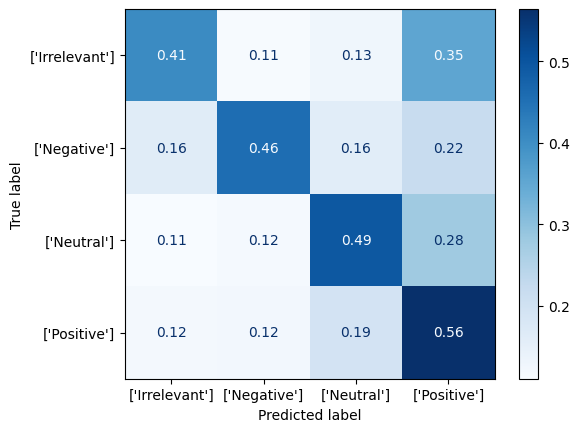

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
titles = [
    ("Confusion Matrix (without normalization)", None),
    ("Confusion Matrix (normalized)", "true")
]

display = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_val,
    y_val,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize="true"
)

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_pred = best_model.predict(X_test)

In [12]:
# MCC
matthews_corrcoef(y_test, y_pred)

np.float64(0.31960377906793075)

In [16]:
# PRECISION
precision_score(y_test, y_pred, average="macro")

0.49166666666666664

In [17]:
# RECALL
recall_score(y_test, y_pred, average="macro")

0.48161075438575446

In [18]:
# F1 SCORE
f1_score(y_test, y_pred, average="macro")

0.4821139114138596